In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# NT-level chec-seq binding score (MNase cut locations)
folders = ["prom_signals"]

# FIMO results
fimo_path = "metadata/fimo_results/promoters/fimo.tsv"

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple

In [4]:
# Find signal file for a replicate across folders
def find_signal_file(replicate: str, folder_paths: List[str]) -> str:
    filename = f"{replicate}_signals.gz"
    for folder in folder_paths:
        file_path = os.path.join(folder, filename)
        if os.path.exists(file_path):
            return file_path
    raise FileNotFoundError(f"Signal file for {replicate} not found.")


# Load all replicates grouped by sample
def load_signal_files_grouped(
    replicates_by_sample: Dict[str, List[str]],
    folder_paths: List[str],
) -> Dict[Tuple[str, str], pd.DataFrame]:

    loaded = {}
    for sample, reps in replicates_by_sample.items():
        for rep in reps:
            path = find_signal_file(rep, folder_paths)
            loaded[(sample, rep)] = pd.read_parquet(path)

    return loaded

In [5]:
# Keep only provided promoters that exist in the data
def choose_promoters(
    loaded_signals: dict,
    promoters: list[str],
) -> list[str]:

    if not loaded_signals:
        raise ValueError("No signals loaded.")

    all_present = set()
    for df in loaded_signals.values():
        all_present.update(df.index.intersection(promoters))

    chosen = [p for p in promoters if p in all_present]

    missing = [p for p in promoters if p not in all_present]
    if missing:
        print(f"Warning: promoters not found and skipped: {missing}")

    if not chosen:
        raise ValueError("None of the provided promoters were found.")

    return chosen

In [6]:
# Extract valid (non-NaN) signal segment starting from first valid value
def valid_segment(row: pd.Series) -> np.ndarray:
    v = row.to_numpy(dtype=float, copy=False)
    if v.size == 0:
        return np.array([], dtype=float)

    mask = ~np.isnan(v)
    if not mask.any():
        return np.array([], dtype=float)

    return v[int(np.argmax(mask)):]


# Get motif center positions for a promoter
def motif_centers_for_promoter(
    fimo: pd.DataFrame,
    motif_id: str,
    promoter: str,
) -> List[float]:

    hits = fimo[
        (fimo["motif_id"] == motif_id) &
        (fimo["sequence_name"] == promoter)
    ]

    if hits.empty:
        return []

    return ((hits["start"] + hits["stop"]) / 2.0).astype(float).tolist()


# Color scheme for samples
def simple_color_scheme():
    return {
        "sample1": [
            (0.52, 0.70, 0.98, 0.70),
            (0.46, 0.66, 0.96, 0.80),
            (0.40, 0.62, 0.94, 0.88),
        ],
        "sample2": [
            (0.99, 0.78, 0.48, 0.70),
            (0.97, 0.67, 0.32, 0.80),
            (0.93, 0.54, 0.18, 0.88),
        ],
        "sample3": [
            (0.60, 0.85, 0.60, 0.70),
            (0.45, 0.78, 0.45, 0.80),
            (0.30, 0.68, 0.30, 0.88),
        ],
    }

In [7]:
def plot_three_samples_split(
    loaded_signals,
    fimo,
    motif_ids,
    motif_labels,
    promoters,
    figsize_per_promoter=(5, 0.8),
):
    center_offset = 150
    line_width = 0.5

    if not loaded_signals:
        raise ValueError("No signals loaded.")
    if len(set(s for s, _ in loaded_signals)) > 3:
        raise ValueError("Supports only three samples.")

    chosen_promoters = choose_promoters(loaded_signals, promoters)

    color_scheme = simple_color_scheme()
    sample_names = list(replicates_by_sample.keys())[:3]

    color_map = {
        s: color_scheme[f"sample{i+1}"]
        for i, s in enumerate(sample_names)
    }

    dark_palette = ["#0b3d91", "#8b0000", "#1f4e79", "#7f0000"]
    motif_colors = {m: dark_palette[i % len(dark_palette)] for i, m in enumerate(motif_ids)}

    H = len(chosen_promoters)
    fig, axes = plt.subplots(
        H, 1,
        figsize=(figsize_per_promoter[0], figsize_per_promoter[1] * H),
        sharex=True
    )
    if H == 1:
        axes = [axes]

    per_panel_limits = []

    for ax, promoter in zip(axes, chosen_promoters):

        template_df = next((df for df in loaded_signals.values() if promoter in df.index), None)
        if template_df is None:
            ax.set_title(f"{promoter} (not found)")
            continue

        seg_template = valid_segment(template_df.loc[promoter])
        if seg_template.size == 0:
            ax.set_title(f"{promoter} (no data)")
            continue

        tss_idx_template = seg_template.size - center_offset

        plotted = {s: [] for s in sample_names}
        left_limit, right_limit = -np.inf, -np.inf

        for s in sample_names:
            reps = [r for (samp, r) in loaded_signals if samp == s]

            for rep, color in zip(reps, color_map[s]):
                df = loaded_signals[(s, rep)]
                if promoter not in df.index:
                    continue

                seg = valid_segment(df.loc[promoter])
                if seg.size == 0:
                    continue

                tss_idx = seg.size - center_offset
                x_vals = np.arange(seg.size) - tss_idx

                left_limit = max(left_limit, x_vals.min())
                right_limit = max(right_limit, x_vals.max())

                plotted[s].append((x_vals, seg, color))

        # determine vertical scaling
        visible_max = max(
            np.nanmax(seg)
            for s in sample_names
            for x, seg, _ in plotted[s]
        )
        third_height = visible_max * 1.15 if visible_max > 0 else 1.2

        # plot samples (stacked thirds)
        for i, s in enumerate(sample_names):
            for x, seg, color in plotted[s]:
                offset = (len(sample_names) - 1 - i) * third_height
                ax.plot(x, offset + seg, color=color, lw=line_width)

        ax.axvline(0, color="#555", lw=0.8, alpha=0.5)

        for i in range(len(sample_names)):
            ax.axhline(i * third_height, color="#555", lw=0.6)

        ax.set_ylim(0, 3 * third_height)

        # motif markers
        yk = 0.9 * (3 * third_height)
        for m in motif_ids:
            centers = motif_centers_for_promoter(fimo, m, promoter)
            xs = np.array(centers) - tss_idx_template
            ax.scatter(xs, np.full_like(xs, yk), color=motif_colors[m], s=20)

        ax.set_yticks([])
        ax.set_ylabel(promoter)

        per_panel_limits.append((left_limit, right_limit))

    # align x-limits
    global_left = -700
    global_right = min(r for l, r in per_panel_limits if np.isfinite(r))

    for ax in axes:
        ax.set_xlim(global_left, global_right)

    # bottom axis labels
    bottom_ax = axes[-1]
    bottom_ax.set_xlabel("Position relative to TSS (bp)")

    ticks = bottom_ax.get_xticks()
    labels = ["TSS" if np.isclose(t, 0) else f"{int(t)}" for t in ticks]
    bottom_ax.set_xticklabels(labels)

    plt.tight_layout()
    return fig

## Data Loading and Plot

/tmp/ipykernel_1504045/1505343599.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bottom_ax.set_xticklabels(labels)


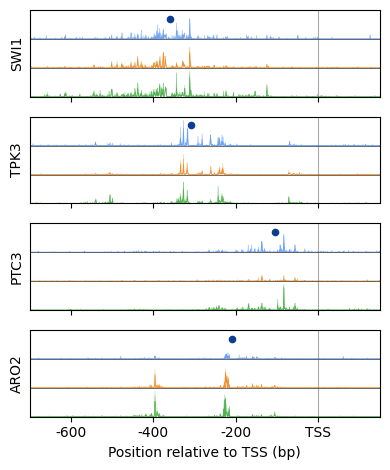

In [8]:
# Define samples and replicates
replicates_by_sample = {
    "ERG": ["ERG_1_S110", "ERG_2_S111", "ERG_3_S112"],
    "ELF1": ["ELF1_1_S212", "ELF1_2_S213", "ELF1_3_S214"],
    "ERG-DBD-ELF1-nonDBD": ["ERG_DBD_ELF1_1_S106", "ERG_DBD_ELF1_2_S107", "ERG_DBD_ELF1_3_S108"],
}

# Load signals
loaded = load_signal_files_grouped(replicates_by_sample, folders)

# Load FIMO
fimo = pd.read_csv(fimo_path, sep="\t")

# Motifs and promoters
motif_ids = ["GABPA.H12CORE.0.PSM.A"]
motif_labels = ["ETS Motif"]
promoters_to_plot = ["SWI1", "TPK3", "PTC3", "ARO2"]

# Plot
fig = plot_three_samples_split(
    loaded_signals=loaded,
    fimo=fimo,
    motif_ids=motif_ids,
    motif_labels={motif_ids[0]: "bZIP AP-1 motif"},
    promoters=promoters_to_plot,
    figsize_per_promoter=(4,1.2),
)

plt.show()
